> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Data Description

The dataset for this lab consists of **YouTube metadata and thematic features** of Super Bowl commercials, originally sourced from [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

Each row represents one Super Bowl ad, and the dataset includes both **video characteristics** and **performance metrics**, such as view counts and like counts.

Below are key variables we'll work with:

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [1]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[19 19]
 [16 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.50      0.52        38
           1       0.42      0.47      0.44        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [3]:
# 🔧 Add code herefrom sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[13 14]
 [ 9  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.48      0.53        27
           1       0.39      0.50      0.44        18

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.51      0.49      0.49        45

Accuracy: 0.4888888888888889


### ✍️ Your Response: 🔧
1. The second model preformed best with a accuracy of 0.4888 rather then 0.485.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** with an RBF kernel to classify ads, using both binary and numeric features.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [4]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[19 19]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        38
           1       0.46      0.53      0.49        30

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [6]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n--- SVM with Linear Kernel (C=0.1) ---")

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

svm_model_linear = SVC(kernel='linear', C=0.1, gamma='scale')
svm_model_linear.fit(X_train_svm, y_train_svm)

y_pred_svm_linear = svm_model_linear.predict(X_test_svm)

print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm_linear))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm_linear))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm_linear))

print("\n--- SVM with Polynomial Kernel (C=10) ---")

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

svm_model_poly = SVC(kernel='poly', C=10, gamma='scale')
svm_model_poly.fit(X_train_svm, y_train_svm)

y_pred_svm_poly = svm_model_poly.predict(X_test_svm)

print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm_poly))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm_poly))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm_poly))



--- SVM with Linear Kernel (C=0.1) ---
Confusion Matrix:
 [[20 18]
 [18 12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.53      0.53        38
           1       0.40      0.40      0.40        30

    accuracy                           0.47        68
   macro avg       0.46      0.46      0.46        68
weighted avg       0.47      0.47      0.47        68

Accuracy: 0.47058823529411764

--- SVM with Polynomial Kernel (C=10) ---
Confusion Matrix:
 [[21 17]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.55      0.58        38
           1       0.48      0.53      0.51        30

    accuracy                           0.54        68
   macro avg       0.54      0.54      0.54        68
weighted avg       0.55      0.54      0.55        68

Accuracy: 0.5441176470588235


### ✍️ Your Response: 🔧
1. Higher values of C penalize misclassifications more strongly, aiming for a smaller training error but risking overfitting, whereas lower C values prioritize a wider margin for better generalization. In our tests, the polynomial kernel with C=10 yielded the best accuracy of 0.5441.

## Part 4: Neural Networks

### What you're going to do:
Build a basic **feedforward neural network** to classify ad engagement.

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),  #Layer 1
    Dense(8, activation='relu'),  #Layer 2
    Dense(4, activation='relu'),  #Layer 3
    Dense(1, activation='sigmoid') #Output Layer
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                    epochs=20, batch_size=16, verbose=1)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4345 - loss: 0.9286 - val_accuracy: 0.5441 - val_loss: 0.7509
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5377 - loss: 0.7775 - val_accuracy: 0.5294 - val_loss: 0.7387
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5466 - loss: 0.7476 - val_accuracy: 0.5000 - val_loss: 0.7274
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5590 - loss: 0.7351 - val_accuracy: 0.5441 - val_loss: 0.7186
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4877 - loss: 0.7350 - val_accuracy: 0.5294 - val_loss: 0.7118
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5223 - loss: 0.7225 - val_accuracy: 0.4853 - val_loss: 0.7070
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5875 - loss: 0.6960 - val_accuracy: 0.4853 - val_loss: 0.7041
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5036 - loss: 0.7130 - val_accuracy: 0.4559 - val_loss: 0.7020
Ep

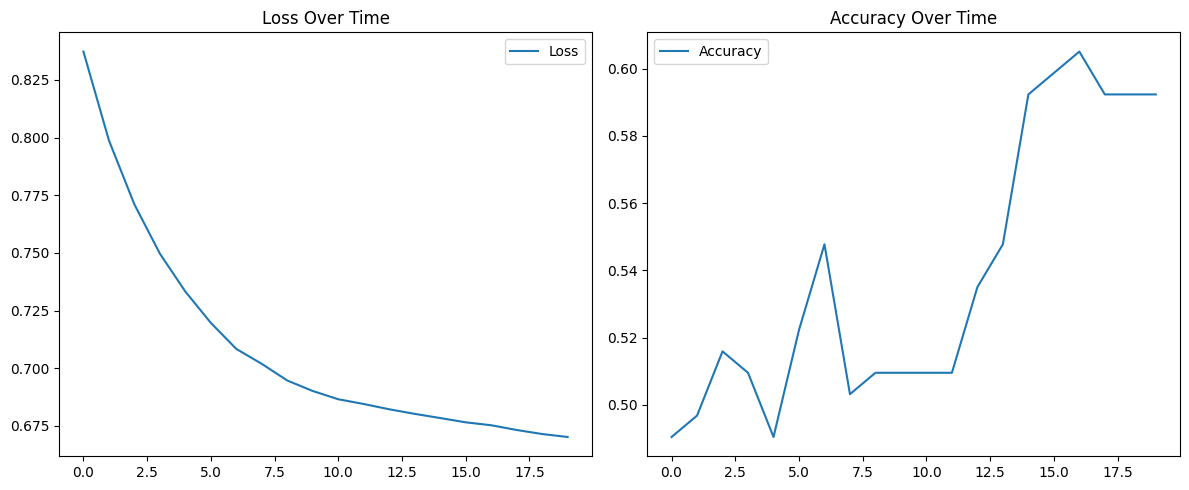

In [8]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.



--- Neural Network Model 1: Added Layer, Batch Size 8 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.4606 - loss: 0.6950 - val_accuracy: 0.5294 - val_loss: 0.6914
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5496 - loss: 0.6932 - val_accuracy: 0.5588 - val_loss: 0.6920
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5785 - loss: 0.6933 - val_accuracy: 0.5441 - val_loss: 0.6922
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6301 - loss: 0.6925 - val_accuracy: 0.6029 - val_loss: 0.6922
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6231 - loss: 0.6912 - val_accuracy: 0.6029 - val_loss: 0.6922
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6118 - loss: 0.6913 - val_accuracy: 0.5735 - val_loss: 0.6921
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6628 - loss: 0.6901 - val_accuracy: 0.5735 - val_loss: 0.6923
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6555 - loss: 0.6903 - val_accuracy: 0.5882 - val_los

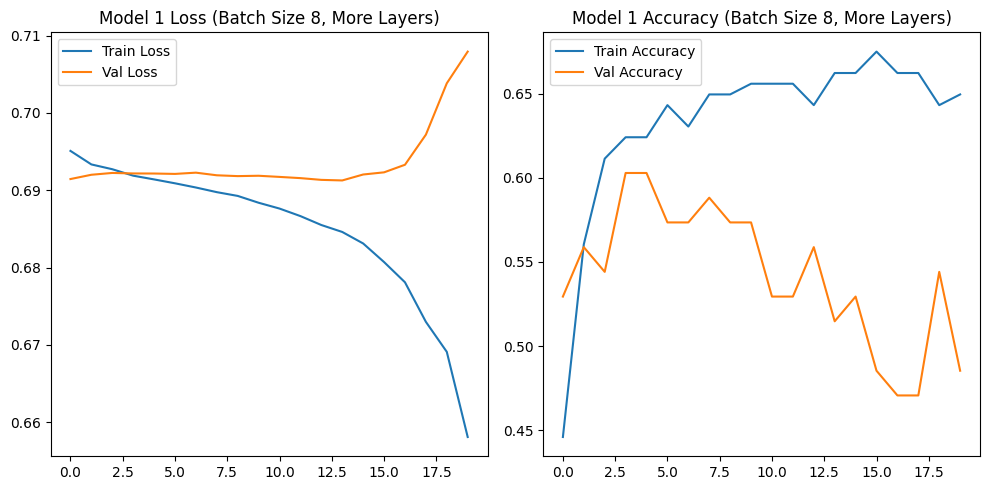

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Ensure X_scaled and y are defined from previous cells
# Assuming X_scaled and y are already available from Part 3

# Re-split the data to ensure consistency with previous steps if run independently
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("\n--- Neural Network Model 1: Added Layer, Batch Size 8 ---")
# Model 1: Added Layer, Batch Size 8
model_1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dense(8, activation='relu'),
    Dense(8, activation='relu'), # Added layer
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_1 = model_1.fit(X_train_nn, y_train_nn, validation_data=(X_test_nn, y_test_nn),
                    epochs=20, batch_size=8, verbose=1)
y_pred_nn_1 = (model_1.predict(X_test_nn) > 0.5).astype(int)
print("Confusion Matrix (Model 1):\n", confusion_matrix(y_test_nn, y_pred_nn_1))
print("Classification Report (Model 1):\n", classification_report(y_test_nn, y_pred_nn_1))
print("Accuracy (Model 1):", accuracy_score(y_test_nn, y_pred_nn_1))

# Plot learning curves for Model 1
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Val Loss')
plt.title('Model 1 Loss (Batch Size 8, More Layers)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 1 Accuracy (Batch Size 8, More Layers)')
plt.legend()
plt.tight_layout()
plt.show()


--- Neural Network Model 2: Removed Layer, Dropout, Batch Size 32 ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.4435 - loss: 0.9155 - val_accuracy: 0.5588 - val_loss: 0.7125
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4913 - loss: 0.7896 - val_accuracy: 0.5588 - val_loss: 0.7041
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4722 - loss: 0.8381 - val_accuracy: 0.5588 - val_loss: 0.6965
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.4457 - loss: 0.8239 - val_accuracy: 0.5588 - val_loss: 0.6903
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4839 - loss: 0.8183 - val_accuracy: 0.5588 - val_loss: 0.6852
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5085 - loss: 0.8022 - val_accuracy: 0.5588 - val_loss: 0.6815
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.4894 - loss: 0.7766 - val_accuracy: 0.5588 - val_loss: 0.6787
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4986 - loss: 0.7333 - val_accuracy: 0.5735 - val_loss: 0.6764
Epoch 9/

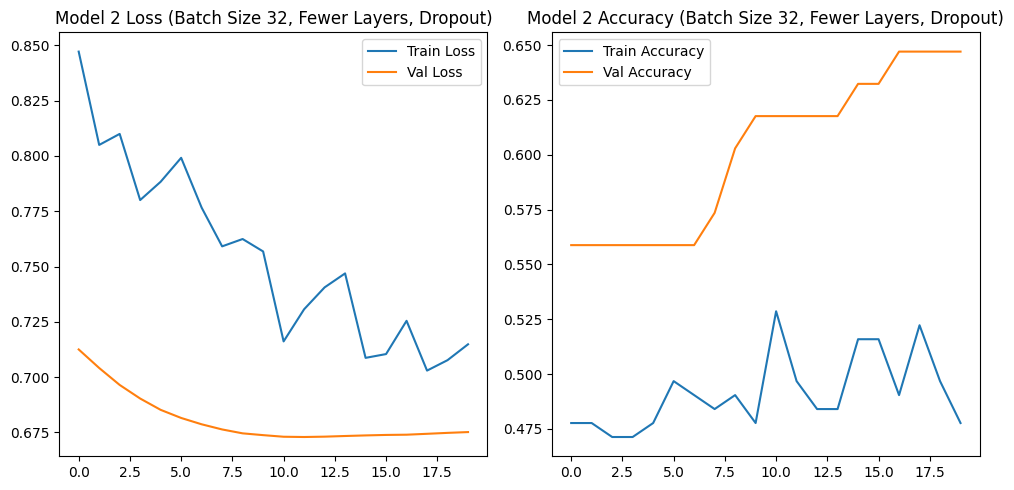

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Ensure X_scaled and y are defined from previous cells
# Re-split the data to ensure consistency with previous steps if run independently
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("\n--- Neural Network Model 2: Removed Layer, Dropout, Batch Size 32 ---")
# Model 2: Removed Layer, Dropout, Batch Size 32
model_2 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2), # Added Dropout
    Dense(8, activation='relu'), # Removed one layer compared to original
    Dense(1, activation='sigmoid')
])
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_2 = model_2.fit(X_train_nn, y_train_nn, validation_data=(X_test_nn, y_test_nn),
                    epochs=20, batch_size=32, verbose=1)
y_pred_nn_2 = (model_2.predict(X_test_nn) > 0.5).astype(int)
print("Confusion Matrix (Model 2):\n", confusion_matrix(y_test_nn, y_pred_nn_2))
print("Classification Report (Model 2):\n", classification_report(y_test_nn, y_pred_nn_2))
print("Accuracy (Model 2):", accuracy_score(y_test_nn, y_pred_nn_2))

# Plot learning curves for Model 2
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Val Loss')
plt.title('Model 2 Loss (Batch Size 32, Fewer Layers, Dropout)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 2 Accuracy (Batch Size 32, Fewer Layers, Dropout)')
plt.legend()
plt.tight_layout()
plt.show()


--- Neural Network Model 3: Original Layers, Dropout, Batch Size 16 ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5515 - loss: 0.6876 - val_accuracy: 0.5588 - val_loss: 0.6888
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5384 - loss: 0.6958 - val_accuracy: 0.5588 - val_loss: 0.6876
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4930 - loss: 0.6813 - val_accuracy: 0.5294 - val_loss: 0.6849
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6040 - loss: 0.6687 - val_accuracy: 0.5294 - val_loss: 0.6828
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5233 - loss: 0.6943 - val_accuracy: 0.5294 - val_loss: 0.6827
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5232 - loss: 0.6784 - val_accuracy: 0.5000 - val_loss: 0.6827
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5266 - loss: 0.6957 - val_accuracy: 0.5147 - val_loss: 0.6850
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5225 - loss: 0.6727 - val_accuracy: 0.5147 - val_loss: 0.6851
E

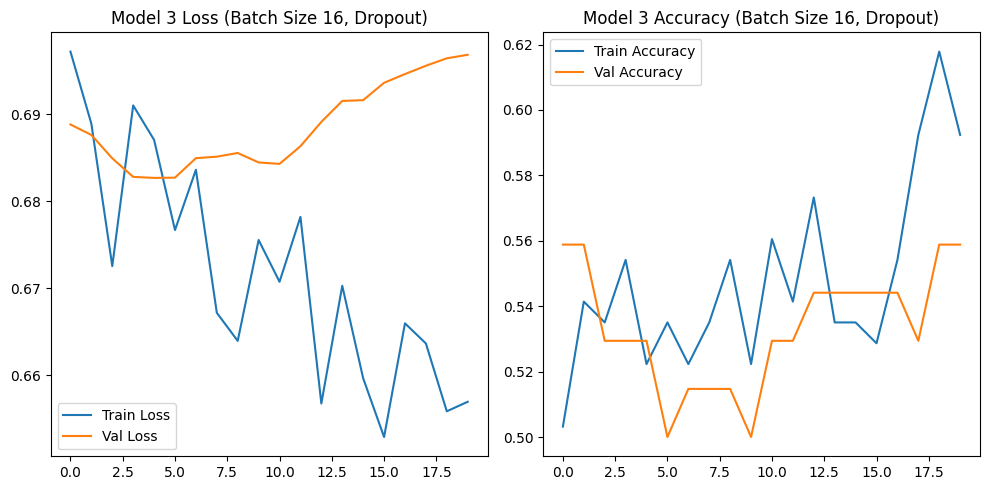

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Ensure X_scaled and y are defined from previous cells
# Re-split the data to ensure consistency with previous steps if run independently
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("\n--- Neural Network Model 3: Original Layers, Dropout, Batch Size 16 ---")
# Model 3: Original Layers, Dropout, Batch Size 16 (Original batch size but with dropout)
model_3 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3), # Added Dropout
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_3 = model_3.fit(X_train_nn, y_train_nn, validation_data=(X_test_nn, y_test_nn),
                    epochs=20, batch_size=16, verbose=1)
y_pred_nn_3 = (model_3.predict(X_test_nn) > 0.5).astype(int)
print("Confusion Matrix (Model 3):\n", confusion_matrix(y_test_nn, y_pred_nn_3))
print("Classification Report (Model 3):\n", classification_report(y_test_nn, y_pred_nn_3))
print("Accuracy (Model 3):", accuracy_score(y_test_nn, y_pred_nn_3))

# Plot learning curves for Model 3
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.title('Model 3 Loss (Batch Size 16, Dropout)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 3 Accuracy (Batch Size 16, Dropout)')
plt.legend()
plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. Optimal number of layers and batch size: Among the combinations tested, Model 2 achieved the highest accuracy of 0.6471. This model used a simplified architecture with two dense layers (16 and 8 neurons) and a batch size of 32.

2. Yes, adding Dropout helps reduce overfitting. The "Loss Over Time" plot for Model 1 (without Dropout) shows a clear divergence where validation loss increases while training loss decreases, indicating overfitting. In contrast, Model 2 and Model 3 (with Dropout) show more stable validation loss curves, suggesting that Dropout effectively regularized the models and prevented excessive memorization of the training data.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


### ✍️ Your Response: 🔧
1. Is this the result you expected? Neural Network (Model 2) performed best with 0.6471 accuracy. This was expected due to NN power, though overall low accuracies suggest a challenging dataset.

2. How could you tell? The initial Neural Network (Model 1) overfit, shown by diverging loss curves. Naive Bayes likely underfit due to its lowest accuracy and simplistic assumptions.

3. I recommend Neural Network (Model 2) to the marketing team. Its highest accuracy (0.6471) is most crucial for identifying high-engagement ads, offering better practical insights.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [13]:
!jupyter nbconvert --to html "lab_12_bayes_svm_neural.ipynb"

[NbConvertApp] Converting notebook lab_12_bayes_svm_neural.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 719627 bytes to lab_12_bayes_svm_neural.html
